# Data Preprocessing

* The experiments use the public ACDC dataset, which contains short-axis cine MRI studies with expert manual contours for the right ventricle ,Myocardium and left ventricle.

* In total 150 patient studies are available; to ensure fair evaluation, we split these into:
              80 patients for training,
              20 for validation and
              50 held out for independent testing.
Each study provides time-resolved frames across the cardiac cycle, with manual annotations at clinically important phases ED and ES frames that serve as ground truth for supervised learning.


In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pdC
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from skimage.transform import resize
import os
import numpy as np
import nibabel as nib
from sklearn.model_selection import train_test_split
import tensorflow as tf

def load_patient_data(directory, target_shape=(224, 224), depth=8, max_samples=None):
    images = []
    masks = []
    sample_count = 0

    def fix_depth(volume, target_depth):
        """Center-crop or pad along depth axis to match target_depth."""
        current_depth = volume.shape[-1]
        if current_depth > target_depth:
            start = (current_depth - target_depth) // 2
            return volume[..., start:start+target_depth]
        elif current_depth < target_depth:
            pad_before = (target_depth - current_depth) // 2
            pad_after = target_depth - current_depth - pad_before
            pad_width = ((0, 0), (0, 0), (pad_before, pad_after))
            return np.pad(volume, pad_width, mode='constant', constant_values=0)
        return volume

    patient_dirs = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])

    for patient_id in patient_dirs:
        patient_path = os.path.join(directory, patient_id)
        if max_samples and sample_count >= max_samples:
            break

        try:
            # Find all relevant files
            nifti_files = [f for f in os.listdir(patient_path) if f.endswith('.nii.gz')]

            # Find ED and ES frames
            ed_img_files = [f for f in nifti_files if "frame01" in f and "_gt" not in f]
            es_img_files = [f for f in nifti_files if "frame" in f and "frame01" not in f and "_gt" not in f]
            ed_mask_files = [f for f in nifti_files if "frame01_gt" in f]
            es_mask_files = [f for f in nifti_files if "frame" in f and "frame01" not in f and "_gt" in f]

            if ed_img_files and es_img_files and ed_mask_files and es_mask_files:
                # Load ED frame
                ed_img = nib.load(os.path.join(patient_path, ed_img_files[0])).get_fdata()
                ed_mask = nib.load(os.path.join(patient_path, ed_mask_files[0])).get_fdata()

                # Load ES frame (take the first one if multiple)
                es_img = nib.load(os.path.join(patient_path, es_img_files[0])).get_fdata()
                es_mask = nib.load(os.path.join(patient_path, es_mask_files[0])).get_fdata()

                # Process each volume
                for vol, msk in [(ed_img, ed_mask), (es_img, es_mask)]:
                    # Resize spatial dimensions (target_shape should be (H, W))
                    vol_resized = resize(vol, target_shape, preserve_range=True, anti_aliasing=True)
                    msk_resized = resize(msk, target_shape, preserve_range=True, order=0, anti_aliasing=False)

                    # Ensure consistent depth
                    vol_fixed = fix_depth(vol_resized, depth)
                    msk_fixed = fix_depth(msk_resized, depth)

                    # Add channel dimension to images
                    vol_fixed = np.expand_dims(vol_fixed, axis=-1)

                    images.append(vol_fixed)
                    masks.append(msk_fixed)
                    sample_count += 1

        except Exception as e:
            print(f"❌ Error loading {patient_id}: {e}")
            continue

    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32)  # (N, H, W, D, 1)
    masks = np.array(masks, dtype=np.uint8)      # (N, H, W, D)

    print(f"✅ Loaded {len(images)} samples with shape {images.shape}")
    print(f"✅ Masks shape: {masks.shape}")

    return images, masks

# -------------------------
# Load and Preprocess Data
# -------------------------
print("Loading training data...")
x_train, y_train = load_patient_data('/content/drive/MyDrive/cardiac/ACDC/database/training',
                                    target_shape=(128, 128), depth=8, max_samples=2000)

print("Loading validation data...")
x_val, y_val = load_patient_data('/content/drive/MyDrive/cardiac/ACDC/database/Val',
                                target_shape=(128, 128), depth=8, max_samples=2000)
# print("Loading validation data...")
# images, masks = load_patient_data('/content/drive/MyDrive/Folder/ACDC/database/testing',
#                                 target_shape=(224, 224), depth=8, max_samples=2000)
# -------------------------
# Normalization - CORRECTED
# -------------------------
def normalize_volumes(volumes):
    """Normalize each volume individually to [0, 1] range"""
    normalized = []
    for vol in volumes:
        # Remove outliers (99th percentile)
        p99 = np.percentile(vol, 99)
        vol_clipped = np.clip(vol, 0, p99)

        # Normalize to [0, 1]
        if np.max(vol_clipped) > 0:
            vol_normalized = vol_clipped / np.max(vol_clipped)
        else:
            vol_normalized = vol_clipped

        normalized.append(vol_normalized)

    return np.array(normalized)
NUM_CLASSES=4
# # print("Normalizing training data...")
x_train = normalize_volumes(x_train)
x_val = normalize_volumes(x_val)
# images = normalize_volumes(images)




print(f"Training data range: [{np.min(x_train):.3f}, {np.max(x_train):.3f}]")
print(f"Validation data range: [{np.min(x_val):.3f}, {np.max(x_val):.3f}]")


In [ ]:
from skimage.transform import resize
import os
import numpy as np
import nibabel as nib
from sklearn.model_selection import train_test_split
import tensorflow as tf

def load_patient_data(directory, target_shape=(224, 224), depth=8, max_samples=None):
    images = []
    masks = []
    sample_count = 0

    def fix_depth(volume, target_depth):
        """Center-crop or pad along depth axis to match target_depth."""
        current_depth = volume.shape[-1]
        if current_depth > target_depth:
            start = (current_depth - target_depth) // 2
            return volume[..., start:start+target_depth]
        elif current_depth < target_depth:
            pad_before = (target_depth - current_depth) // 2
            pad_after = target_depth - current_depth - pad_before
            pad_width = ((0, 0), (0, 0), (pad_before, pad_after))
            return np.pad(volume, pad_width, mode='constant', constant_values=0)
        return volume

    patient_dirs = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])

    for patient_id in patient_dirs:
        patient_path = os.path.join(directory, patient_id)
        if max_samples and sample_count >= max_samples:
            break

        try:
            # Find all relevant files
            nifti_files = [f for f in os.listdir(patient_path) if f.endswith('.nii.gz')]

            # Find ED and ES frames
            ed_img_files = [f for f in nifti_files if "frame01" in f and "_gt" not in f]
            es_img_files = [f for f in nifti_files if "frame" in f and "frame01" not in f and "_gt" not in f]
            ed_mask_files = [f for f in nifti_files if "frame01_gt" in f]
            es_mask_files = [f for f in nifti_files if "frame" in f and "frame01" not in f and "_gt" in f]

            if ed_img_files and es_img_files and ed_mask_files and es_mask_files:
                # Load ED frame
                ed_img = nib.load(os.path.join(patient_path, ed_img_files[0])).get_fdata()
                ed_mask = nib.load(os.path.join(patient_path, ed_mask_files[0])).get_fdata()

                # Load ES frame (take the first one if multiple)
                es_img = nib.load(os.path.join(patient_path, es_img_files[0])).get_fdata()
                es_mask = nib.load(os.path.join(patient_path, es_mask_files[0])).get_fdata()

                # Process each volume
                for vol, msk in [(ed_img, ed_mask), (es_img, es_mask)]:
                    # Resize spatial dimensions (target_shape should be (H, W))
                    vol_resized = resize(vol, target_shape, preserve_range=True, anti_aliasing=True)
                    msk_resized = resize(msk, target_shape, preserve_range=True, order=0, anti_aliasing=False)

                    # Ensure consistent depth
                    vol_fixed = fix_depth(vol_resized, depth)
                    msk_fixed = fix_depth(msk_resized, depth)

                    # Add channel dimension to images
                    vol_fixed = np.expand_dims(vol_fixed, axis=-1)

                    images.append(vol_fixed)
                    masks.append(msk_fixed)
                    sample_count += 1

        except Exception as e:
            print(f"❌ Error loading {patient_id}: {e}")
            continue

    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32)  # (N, H, W, D, 1)
    masks = np.array(masks, dtype=np.uint8)      # (N, H, W, D)

    print(f"✅ Loaded {len(images)} samples with shape {images.shape}")
    print(f"✅ Masks shape: {masks.shape}")

    return images, masks

# -------------------------
# Load and Preprocess Data
# -------------------------
print("Loading test data...")
x_test, y_test = load_patient_data('/content/drive/MyDrive/cardiac/ACDC/database/testing',
                                    target_shape=(128, 128), depth=8, max_samples=2000)
# print("Loading validation data...")
# images, masks = load_patient_data('/content/drive/MyDrive/Folder/ACDC/database/testing',
#                                 target_shape=(224, 224), depth=8, max_samples=2000)
# -------------------------
# Normalization - CORRECTED
# -------------------------
def normalize_volumes(volumes):
    """Normalize each volume individually to [0, 1] range"""
    normalized = []
    for vol in volumes:
        # Remove outliers (99th percentile)
        p99 = np.percentile(vol, 99)
        vol_clipped = np.clip(vol, 0, p99)

        # Normalize to [0, 1]
        if np.max(vol_clipped) > 0:
            vol_normalized = vol_clipped / np.max(vol_clipped)
        else:
            vol_normalized = vol_clipped

        normalized.append(vol_normalized)

    return np.array(normalized)
NUM_CLASSES=4
# # print("Normalizing training data...")
x_test = normalize_volumes(x_test)

# images = normalize_volumes(images)



Loading test data...
✅ Loaded 100 samples with shape (100, 128, 128, 8, 1)
✅ Masks shape: (100, 128, 128, 8)


In [ ]:
from skimage.transform import resize
import os
import numpy as np
import nibabel as nib
from sklearn.model_selection import train_test_split
import tensorflow as tf

def load_patient_data_separate(directory, target_shape=(224, 224), depth=8, max_samples=None):
    ed_images, ed_masks = [], []
    es_images, es_masks = [],[]
    sample_count = 0

    def fix_depth(volume, target_depth):
        """Center-crop or pad along depth axis to match target_depth."""
        current_depth = volume.shape[-1]
        if current_depth > target_depth:
            start = (current_depth - target_depth) // 2
            return volume[..., start:start+target_depth]
        elif current_depth < target_depth:
            pad_before = (target_depth - current_depth) // 2
            pad_after = target_depth - current_depth - pad_before
            pad_width = ((0, 0), (0, 0), (pad_before, pad_after))
            return np.pad(volume, pad_width, mode='constant', constant_values=0)
        return volume

    patient_dirs = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])

    for patient_id in patient_dirs:
        patient_path = os.path.join(directory, patient_id)
        if max_samples and sample_count >= max_samples:
            break

        try:
            nifti_files = [f for f in os.listdir(patient_path) if f.endswith('.nii.gz')]

            # Find ED (frame01) and ES (later frame)
            ed_img_files = [f for f in nifti_files if "frame01" in f and "_gt" not in f]
            es_img_files = [f for f in nifti_files if "frame" in f and "frame01" not in f and "_gt" not in f]
            ed_mask_files = [f for f in nifti_files if "frame01_gt" in f]
            es_mask_files = [f for f in nifti_files if "frame" in f and "frame01" not in f and "_gt" in f]

            if ed_img_files and es_img_files and ed_mask_files and es_mask_files:
                # Load ED
                ed_img = nib.load(os.path.join(patient_path, ed_img_files[0])).get_fdata()
                ed_mask = nib.load(os.path.join(patient_path, ed_mask_files[0])).get_fdata()

                # Load ES
                es_img = nib.load(os.path.join(patient_path, es_img_files[0])).get_fdata()
                es_mask = nib.load(os.path.join(patient_path, es_mask_files[0])).get_fdata()

                # Resize and fix depth (ED)
                ed_img_resized = resize(ed_img, target_shape, preserve_range=True, anti_aliasing=True)
                ed_mask_resized = resize(ed_mask, target_shape, preserve_range=True, order=0, anti_aliasing=False)
                ed_img_fixed = fix_depth(ed_img_resized, depth)
                ed_mask_fixed = fix_depth(ed_mask_resized, depth)
                ed_img_fixed = np.expand_dims(ed_img_fixed, axis=-1)

                # Resize and fix depth (ES)
                es_img_resized = resize(es_img, target_shape, preserve_range=True, anti_aliasing=True)
                es_mask_resized = resize(es_mask, target_shape, preserve_range=True, order=0, anti_aliasing=False)
                es_img_fixed = fix_depth(es_img_resized, depth)
                es_mask_fixed = fix_depth(es_mask_resized, depth)
                es_img_fixed = np.expand_dims(es_img_fixed, axis=-1)

                # Append separately
                ed_images.append(ed_img_fixed)
                ed_masks.append(ed_mask_fixed)
                es_images.append(es_img_fixed)
                es_masks.append(es_mask_fixed)

                sample_count += 1

        except Exception as e:
            print(f"❌ Error loading {patient_id}: {e}")
            continue

    # Convert to numpy arrays
    ed_images = np.array(ed_images, dtype=np.float32)
    ed_masks = np.array(ed_masks, dtype=np.uint8)
    es_images = np.array(es_images, dtype=np.float32)
    es_masks = np.array(es_masks, dtype=np.uint8)

    print(f"✅ Loaded {len(ed_images)} ED samples, shape: {ed_images.shape}")
    print(f"✅ Loaded {len(es_images)} ES samples, shape: {es_images.shape}")

    return ed_images, ed_masks, es_images, es_masks
print("Loading test data...")
ed_test, ed_mask, es_test, es_mask = load_patient_data_separate(
    '/content/drive/MyDrive/cardiac/ACDC/database/testing',
    target_shape=(128, 128),
    depth=8,
    max_samples=2000
)
def normalize_volumes(volumes):
    """Normalize each volume individually to [0, 1] range"""
    normalized = []
    for vol in volumes:
        # Remove outliers (99th percentile)
        p99 = np.percentile(vol, 99)
        vol_clipped = np.clip(vol, 0, p99)

        # Normalize to [0, 1]
        if np.max(vol_clipped) > 0:
            vol_normalized = vol_clipped / np.max(vol_clipped)
        else:
            vol_normalized = vol_clipped

        normalized.append(vol_normalized)

    return np.array(normalized)
ed_test = normalize_volumes(ed_test)
es_test = normalize_volumes(es_test)



Loading test data...
✅ Loaded 50 ED samples, shape: (50, 128, 128, 8, 1)
✅ Loaded 50 ES samples, shape: (50, 128, 128, 8, 1)


To improve training diversity and model robustness, on-the-fly data augmentation is applied during training. The augmentations includes:
* random horizontal and vertical flips,
* rotations within ±20°, and
* Elastic deformations (α = 40, σ = 5).

These transformations simulate variations caused by patient positioning, breathing, motion, and myocardial deformation during the cardiac cycle. Applied probabilistically, they expose the model to diverse samples each epoch, helping it learn deformation-invariant features and reducing overfitting.


In [ ]:
import numpy as np
import scipy.ndimage as ndi

def vertical_flip(volume, mask):
    return np.flip(volume, axis=0), np.flip(mask, axis=0)

def horizontal_flip(volume, mask):
    return np.flip(volume, axis=1), np.flip(mask, axis=1)

def rotate(volume, mask, max_angle=20):
    angle = np.random.uniform(-max_angle, max_angle)
    v = ndi.rotate(volume, angle, axes=(0, 1), reshape=False, order=1, mode="nearest")
    m = ndi.rotate(mask, angle, axes=(0, 1), reshape=False, order=0, mode="nearest")
    return v, m

def elastic_deformation(volume, mask, alpha=40, sigma=5, random_state=None):
    if random_state is None:
        random_state = np.random.RandomState(None)

    shape = volume.shape[:2]  # (H, W)
    dz = volume.shape[2]      # depth (slices)

    dx = ndi.gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
    dy = ndi.gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

    vol_deformed, mask_deformed = np.empty_like(volume), np.empty_like(mask)

    for z in range(dz):
        vol_deformed[..., z, 0] = ndi.map_coordinates(
            volume[..., z, 0], indices, order=1, mode="reflect"
        ).reshape(shape)
        mask_deformed[..., z] = ndi.map_coordinates(
            mask[..., z], indices, order=0, mode="reflect"
        ).reshape(shape)

    return vol_deformed, mask_deformed
def build_augmented_dataset(x, y):
    """
    Build dataset = Originals + VFlip + HFlip + Rotation + Elastic
    Total = 5 × dataset size
    """
    originals = [x[i].astype(np.float32) for i in range(len(x))]
    masks_ori = [y[i].astype(np.uint8)   for i in range(len(y))]

    vflips, vflips_masks = [], []
    hflips, hflips_masks = [], []
    rotations, rotations_masks = [], []
    # elastics, elastics_masks = [], []

    for i in range(len(x)):
        v, m = vertical_flip(x[i], y[i])
        vflips.append(v); vflips_masks.append(m)

        v, m = horizontal_flip(x[i], y[i])
        hflips.append(v); hflips_masks.append(m)

        v, m = rotate(x[i], y[i])
        rotations.append(v); rotations_masks.append(m)

        # v, m = elastic_deformation(x[i], y[i])
        # elastics.append(v); elastics_masks.append(m)

    all_vols = np.array(originals + vflips + hflips + rotations, dtype=np.float32)
    all_masks = np.array(masks_ori + vflips_masks + hflips_masks + rotations_masks, dtype=np.uint8)

    return all_vols, all_masks
x_train_final, y_train_final = build_augmented_dataset(x_train, y_train)

print("Originals:", len(x_train))
print("Final Dataset:", x_train_final.shape, y_train_final.shape)  # (800, H, W, D, C) if 3D


Originals: 160
Final Dataset: (640, 128, 128, 8, 1) (640, 128, 128, 8)


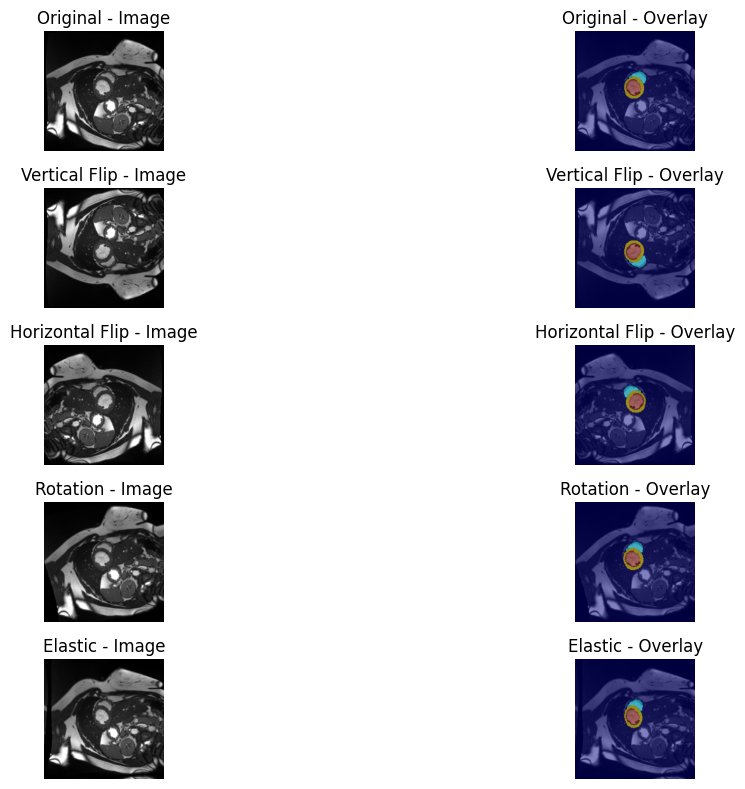

In [ ]:
# sample before and after augmentation
#sample before and after augmentation
import matplotlib.pyplot as plt

# Select the single image and mask
img = es_test[0]
mask = es_mask[0]

# Apply all augmentations
augmented_images = []
augmented_masks = []

# Original
augmented_images.append(img.astype(np.float32))
augmented_masks.append(mask.astype(np.uint8))

# Vertical flip
v_img, v_mask = vertical_flip(img, mask)
augmented_images.append(v_img)
augmented_masks.append(v_mask)

# Horizontal flip
h_img, h_mask = horizontal_flip(img, mask)
augmented_images.append(h_img)
augmented_masks.append(h_mask)

# Rotation
r_img, r_mask = rotate(img, mask)
augmented_images.append(r_img)
augmented_masks.append(r_mask)

# Elastic deformation
e_img, e_mask = elastic_deformation(img, mask)
augmented_images.append(e_img)
augmented_masks.append(e_mask)

# Plot all augmentations
plt.figure(figsize=(15, 8))
titles = ['Original', 'Vertical Flip', 'Horizontal Flip', 'Rotation', 'Elastic']

for i in range(len(augmented_images)):
    slice_idx = augmented_images[i].shape[2] // 2  # central slice
    img_slice = augmented_images[i][:, :, slice_idx, 0]  # (H,W)
    mask_slice = augmented_masks[i][:, :, slice_idx]     # (H,W)

    # Image
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img_slice, cmap='gray')
    plt.title(f"{titles[i]} - Image")
    plt.axis('off')

    # Overlay
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(img_slice, cmap='gray')
    plt.imshow(mask_slice, cmap='jet', alpha=0.5)
    plt.title(f"{titles[i]} - Overlay")
    plt.axis('off')

plt.tight_layout()
plt.show()

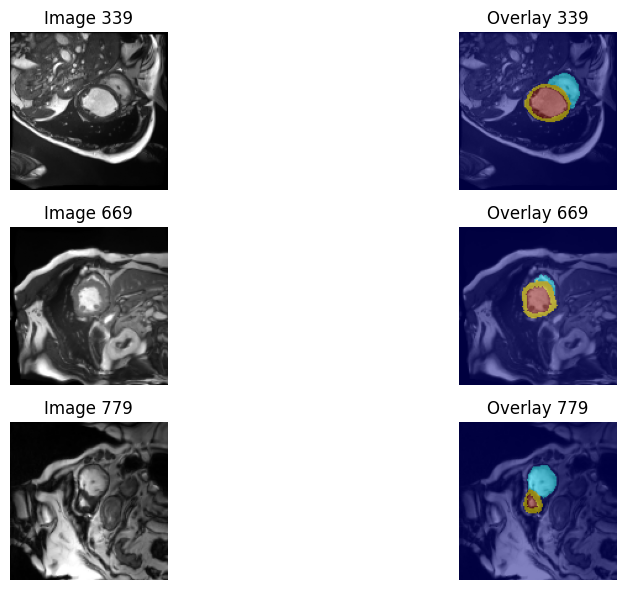

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_samples(images, masks, num_samples=3):
    """
    Visualize random samples (image slice + mask overlay).
    images: (N, H, W, D, 1)
    masks:  (N, H, W, D) with integer labels
    """
    plt.figure(figsize=(12, 6))

    for i in range(num_samples):
        idx = np.random.randint(0, len(images))
        img = images[idx]    # (H,W,D,1)
        mask = masks[idx]    # (H,W,D)

        # Show central slice
        slice_idx = img.shape[2] // 2
        img_slice = img[:, :, slice_idx, 0]   # (H,W)
        mask_slice = mask[:, :, slice_idx]    # (H,W), integer labels

        # Original image
        plt.subplot(num_samples, 2, 2*i+1)
        plt.imshow(img_slice, cmap='gray')
        plt.title(f"Image {idx}")
        plt.axis('off')

        # Overlay mask on image
        plt.subplot(num_samples, 2, 2*i+2)
        plt.imshow(img_slice, cmap='gray')
        plt.imshow(mask_slice, cmap='jet', alpha=0.5)  # integer mask
        plt.title(f"Overlay {idx}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Example: visualize 3 random samples
visualize_samples(x_train_final, y_train_final, num_samples=3)


In [ ]:

BATCH_SIZE = 1 # Adjust based on GPU memory
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train_final, y_train_final))
    .shuffle(buffer_size=len(x_train))   # Shuffle before batching
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [ ]:
for images, masks in train_ds.take(1):
    print("Images batch shape:", images.shape,images.dtype)
    print("Masks batch shape:", masks.shape,masks.dtype)


Images batch shape: (1, 128, 128, 8, 1) <dtype: 'float32'>
Masks batch shape: (1, 128, 128, 8) <dtype: 'int32'>


In [ ]:
import gc

# list of variables you want to delete
to_delete = ['model']

for var in to_delete:
    if var in globals():
        del globals()[var]

# force garbage collection
gc.collect()


40436

In [ ]:
import gc

# list of variables you want to delete
to_delete = ['train_ds','val_ds']

for var in to_delete:
    if var in globals():
        del globals()[var]

# force garbage collection
gc.collect()


0